In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict
from model_ranking import (
    load_h5,
    get_output_paths,
    calculate_correlation_statistics,
)

from pathlib import Path


In [3]:
NA_UNet_source_models = {
    "EPFL": "E_model_NA2",
    "Hmito": "Hm_model_NA2",
    "Rmito": "Rm_model_NA2",
    "VNC": "V_model_NA2",
}
Res_source_models = {
    "EPFL": "E_model_Res1",
    "Hmito": "Hm_model_Res1",
    "Rmito": "Rm_model_Res1",
    "VNC": "V_model_Res1",
}

Unetr_source_models = {
    "EPFL": "E_model_Unetr2",
    "Hmito": "Hm_model_Unetr2",
    "Rmito": "Rm_model_Unetr2",
}
Unet_source_models={
    "EPFL": "E_model5",
    "Hmito": "Hm_model4",
    "Rmito": "Rm_model4",
    "VNC": "V_model2",
}

In [4]:
source_datasets = ["EPFL", "Hmito", "Rmito", "VNC"]
target_datasets = ["EPFL", "Hmito", "Rmito", "VNC"]
approach="consistency"
result_folder="P_full"
summary_results_postfix = "_full"
base_dir_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria"
ccfv_base_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/ccfv_scores"
perf_key = "hard_f1"
source_model_types = [
    NA_UNet_source_models, 
    Res_source_models, 
    Unet_source_models, 
    Unetr_source_models
]

In [5]:
per_target_f1_means: Dict[str, List[float]] = {}
per_target_f1_medians: Dict[str, List[float]]  = {}
per_target_ccfv_scores: Dict[str, List[float]] = {}
per_target_model_names: Dict[str, List[str]] = {}
per_target_per_model_ccfv_scores: Dict[str, Dict[str, float]] = {}
per_target_per_model_f1_means: Dict[str, Dict[str, float]] = {}
per_target_per_model_f1_medians: Dict[str, Dict[str, float]] = {}
for target in target_datasets:
    per_model_f1_medians: Dict[str, float] = {}
    per_model_f1_means: Dict[str, float] = {}
    per_model_ccfv_scores: Dict[str, float] = {}
    for model_type in source_model_types:
        sources = list(model_type.keys())
        for source in sources:
            if (target == "VNC") and ("VNC" in sources):
            # remove VNC from sources
                sources.remove("VNC")

            #print(f'{source} -> {target}')
            output_path = get_output_paths(
                source,
                target,
                selected_augmentations={"none": []},
                selected_norms=[None],
                source_model=model_type[source],
                output=f"metric_summary{summary_results_postfix}.h5",
                approach=approach,
                result_folder=result_folder,
                base_dir_path=base_dir_path,
            )
            assert len(output_path) == 1, f"num paths found == {len(output_path)}"
            f1_mean = load_h5(output_path[0], f"{perf_key}_mean")[1]
            f1_median = load_h5(output_path[0], f"{perf_key}_median")[1]
            per_model_f1_means[model_type[source]] = f1_mean
            per_model_f1_medians[model_type[source]] = f1_median
            ccfv_score_path = Path(ccfv_base_path) / f"{source}_to_{target}" / model_type[source] /"ccfv_score.npy"
            ccfv_score = float(np.load(ccfv_score_path))
            per_model_ccfv_scores[model_type[source]] = ccfv_score
    per_target_f1_means[target] = list(per_model_f1_means.values())
    per_target_f1_medians[target] = list(per_model_f1_medians.values())
    per_target_ccfv_scores[target] = list(per_model_ccfv_scores.values())
    per_target_model_names[target] = list(per_model_ccfv_scores.keys())
    per_target_per_model_ccfv_scores[target] = per_model_ccfv_scores
    per_target_per_model_f1_means[target] = per_model_f1_means
    per_target_per_model_f1_medians[target] = per_model_f1_medians


In [7]:
import json
import os
from typing import Any
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/ccfv"
if not os.path.exists(save_path):
    os.makedirs(save_path)

with open(os.path.join(save_path, f"transfer_CCFV_scores.json"), "w") as f:
    results: Dict[str, Any] = {
        "transfer_scores": convert_numpy_types(per_target_per_model_ccfv_scores),
    }
    json.dump(results, f, indent=4)

with open(os.path.join(save_path, f"transfer_performance_F1_scores.json"), "w") as f:
    results: Dict[str, Any] = {
        "performance_scores": convert_numpy_types(per_target_per_model_f1_medians),
    }
    json.dump(results, f, indent=4)

Target: EPFL
Target: Hmito
Target: Rmito
Target: VNC


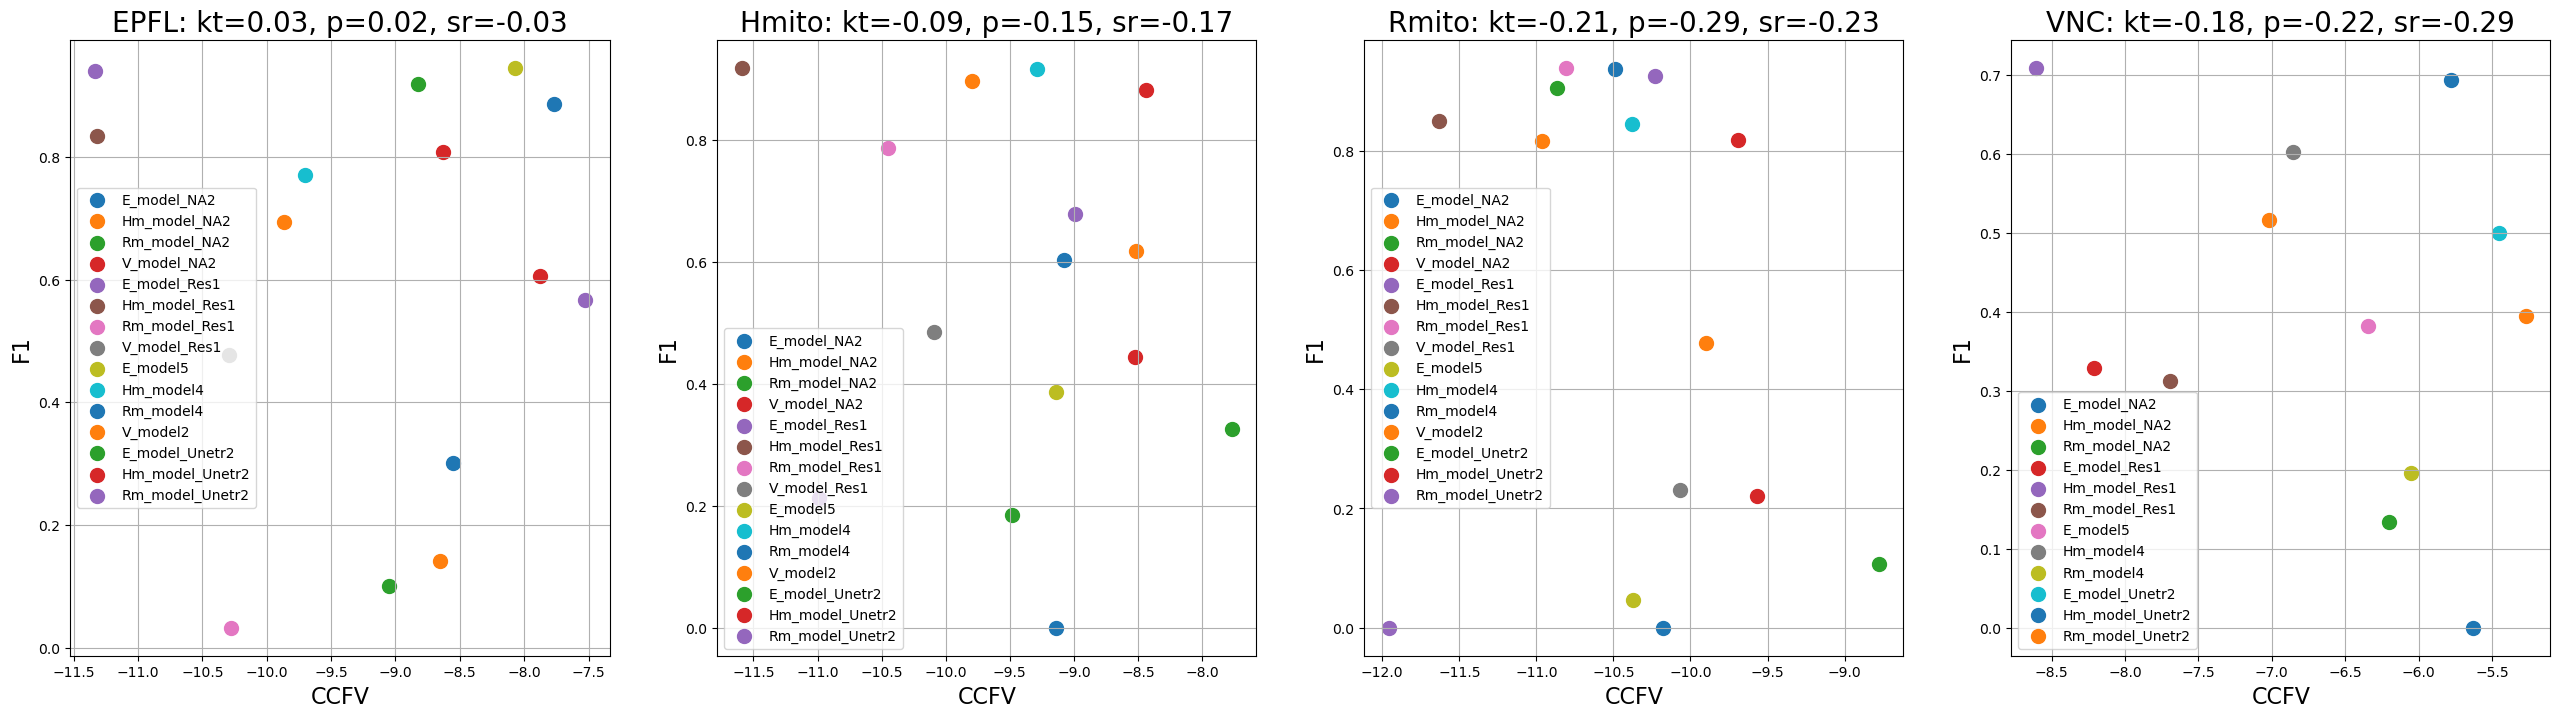

In [6]:
_, axs = plt.subplots(1, 4, figsize=(32, 8))
axs = axs.flatten()
for i, target in enumerate(target_datasets):
    print(f"Target: {target}")
    kendall_tau, pearson, spearman = calculate_correlation_statistics(
        np.expand_dims(np.array((per_target_ccfv_scores[target])), axis=1),
        np.array((per_target_f1_medians[target])),
    )
    for j, model_name in enumerate(per_target_model_names[target]):
        axs[i].scatter(per_target_ccfv_scores[target][j], per_target_f1_medians[target][j], label=model_name, s=100)
    axs[i].set_xlabel("CCFV", fontsize=16)
    axs[i].set_ylabel("F1", fontsize=16)
    axs[i].set_title(f"{target}: kt={kendall_tau[0, 0]:.2f}, p={pearson[0, 0]:.2f}, sr={spearman[0, 0]:.2f}", fontsize=20)
    axs[i].legend()
    axs[i].grid()
plt.show()